<table style="width: 100%; border-style: none;">
<tr style="border-style: none">
<td style="border-style: none; width: 1%; text-align: left; font-size: 16px">Institut f&uuml;r Theoretische Physik<br /> Universit&auml;t zu K&ouml;ln</td>
<td style="border-style: none; width: 1%; font-size: 16px">&nbsp;</td>
<td style="border-style: none; width: 1%; text-align: right; font-size: 16px">Prof. Dr. Matteo Rizzi
</tr>
</table>
<hr>
<h1 style="font-weight:bold; text-align: center; margin: 0px; font-size: 30px; padding:0px;">Computerphysik</h1>
<h1 style="font-weight:bold; text-align: center; margin: 0px; font-size: 30px; padding:0px;">Übungsblatt 2</h1>
<hr>
<h3 style="font-weight:bold; text-align: center; margin: 0px; font-size: 20px; padding:0px; margin-bottom: 20px;">Sommersemester 2026</h3>
<hr>



<table style="border-style: none; width: 100%"><tr style="border-style: none;">
<td style="border-style: none; width: 1%; text-align: left; font-size: 25px; font-weight: bold; text-decoration: underline">Aufgaben auf Übungsblatt 2</td>
<td style="border-style: none; width: 1%; text-align: right; font-size: 15px"></td></tr></table>

- Aufgabe 02_01 
- **Aufgabe 02_02** 


<table style="border-style: none; width: 100%"><tr style="border-style: none;">
<td style="border-style: none; width: 1%; text-align: left; font-size: 25px; font-weight: bold; text-decoration: underline">Noisy Data am Beispiel der COVID19 Daten 02_02</td>


In diesem Notebook wollen wir am Beispiel der COVID19 Daten des Robert-Koch-Instituts verrauschte Daten plotten, glätten sowie numerisch integrieren und ableiten. 
In Deutschland ist die autorative Quelle für Corona-Daten das Robert Koch Institut, kurz [RKI](https://www.rki.de/DE/Home/homepage_node.html), welches tagesaktuelle Daten unter anderem in ihrem sehr informativen [Dashboard](https://corona.rki.de) darstellt.

Zuerst wollen wir die Covid-19 Roh-Daten für das Land Nordrhein-Westfalen, die dem RKI Dashboard zu Grund liegen, in das Jupyter Notebook einlesen. Sie können den Datensatz des RKI [von dessen Webseite](https://npgeo-corona-npgeo-de.hub.arcgis.com/datasets/dd4580c810204019a7b8eb3e0b329dd6_0)
bzw. [hier](https://npgeo-corona-npgeo-de.hub.arcgis.com/datasets/a99afefd4258435f8af660b6cbed9bf7_0) als `.csv`-Datei herunterladen oder verwenden die bereits vorliegende Datei. Das Einlesen der Daten geschieht dann als `DataFrame` mittels `CSVFiles` und `DataFrames`.
Führen Sie als erstes die folgende Zeile aus um alle benötigten Pakete zu laden. Sollte Sie eines nicht installiert haben, können Sie es wie folgt installieren:
```
    using Pkg
    Pkg.add("Name des Pakets")
```

In [1]:
using Plots
using CSVFiles
using DataFrames
using Statistics
using Dates

### a) Tabellen als DataFrame einlesen und verarbeiten

In [2]:
raw_data = DataFrame(load("RKI_COVID19_Nordrhein-Westfalen.csv"))
first(raw_data, 6)

Row,IdBundesland,Bundesland,IdLandkreis,Landkreis,Altersgruppe,Altersgruppe2,Geschlecht,Meldedatum,Refdatum,IstErkrankungsbeginn,NeuerFall,NeuerTodesfall,NeuGenesen,AnzahlFall,AnzahlTodesfall,AnzahlGenesen,Datenstand,ObjectId
,Int64,String,Int64,String,String,String,String,String,String,Int64,Int64,Int64,Int64,Int64,Int64,Int64,String,Int64
1,5,Nordrhein-Westfalen,5111,SK Düsseldorf,A00-A04,Nicht übermittelt,M,2021/03/30 00:00:00+00,2021/03/30 00:00:00+00,0,0,-9,-9,2,0,0,"22.04.2021, 00:00 Uhr",1
2,5,Nordrhein-Westfalen,5111,SK Düsseldorf,A00-A04,Nicht übermittelt,M,2021/03/31 00:00:00+00,2021/03/16 00:00:00+00,1,0,-9,0,1,0,1,"22.04.2021, 00:00 Uhr",2
3,5,Nordrhein-Westfalen,5111,SK Düsseldorf,A00-A04,Nicht übermittelt,M,2021/03/31 00:00:00+00,2021/03/22 00:00:00+00,1,0,-9,0,1,0,1,"22.04.2021, 00:00 Uhr",3
4,5,Nordrhein-Westfalen,5111,SK Düsseldorf,A00-A04,Nicht übermittelt,M,2021/03/31 00:00:00+00,2021/03/30 00:00:00+00,1,0,-9,0,1,0,1,"22.04.2021, 00:00 Uhr",4
5,5,Nordrhein-Westfalen,5111,SK Düsseldorf,A00-A04,Nicht übermittelt,M,2021/03/31 00:00:00+00,2021/03/31 00:00:00+00,0,0,-9,0,1,0,1,"22.04.2021, 00:00 Uhr",5
6,5,Nordrhein-Westfalen,5111,SK Düsseldorf,A00-A04,Nicht übermittelt,M,2021/04/01 00:00:00+00,2021/03/26 00:00:00+00,1,0,-9,0,1,0,1,"22.04.2021, 00:00 Uhr",6


Die Tabelle enthält einige Spalten deren Namen mit der Funktion `names(df::DataFrame)` ausgegeben werden. Spalten des DataFrames können mit Indizes oder einfach dem Spaltennamen
aufgerufen werden `df.Spaltenname`. Da uns hier nur das Meldedatum und die Fallzahlen interessieren, wählen wir die entsprechenden Spalten mithilfe der Funktion
`select!(df::DataFrame, :Spalte_A, :Spalte_B, ...)`.

In [3]:
println( names(raw_data) )

["IdBundesland", "Bundesland", "IdLandkreis", "Landkreis", "Altersgruppe", "Altersgruppe2", "Geschlecht", "Meldedatum", "Refdatum", "IstErkrankungsbeginn", "NeuerFall", "NeuerTodesfall", "NeuGenesen", "AnzahlFall", "AnzahlTodesfall", "AnzahlGenesen", "Datenstand", "ObjectId"]


In [4]:
data = select(raw_data, :Meldedatum, :AnzahlFall, :Landkreis)
first(data, 6)

Row,Meldedatum,AnzahlFall,Landkreis
,String,Int64,String
1,2021/03/30 00:00:00+00,2,SK Düsseldorf
2,2021/03/31 00:00:00+00,1,SK Düsseldorf
3,2021/03/31 00:00:00+00,1,SK Düsseldorf
4,2021/03/31 00:00:00+00,1,SK Düsseldorf
5,2021/03/31 00:00:00+00,1,SK Düsseldorf
6,2021/04/01 00:00:00+00,1,SK Düsseldorf


Jetzt wollen wir den Verlauf der Gesamtanzahl aller Covid-19 Fälle gegen das zugehörige Meldedatum untersuchen, 
welches zuerst einmal in der nachfolgenden Zelle erstellt und danach geplottet wird. Die Funktion `filter( func: x-> {true,false}, df::DataFrame )` (pseudocode) wendet eine Funktion mit
Ergebnis `true` oder `false` pro Zeile an und gibt nur Zeilen mit `true` aus.

In [5]:
# Beispiel
cases_w = filter(c->c.Geschlecht == "W", raw_data)
first(cases_w, 6)

Row,IdBundesland,Bundesland,IdLandkreis,Landkreis,Altersgruppe,Altersgruppe2,Geschlecht,Meldedatum,Refdatum,IstErkrankungsbeginn,NeuerFall,NeuerTodesfall,NeuGenesen,AnzahlFall,AnzahlTodesfall,AnzahlGenesen,Datenstand,ObjectId
,Int64,String,Int64,String,String,String,String,String,String,Int64,Int64,Int64,Int64,Int64,Int64,Int64,String,Int64
1,5,Nordrhein-Westfalen,5111,SK Düsseldorf,A00-A04,Nicht übermittelt,W,2021/02/17 00:00:00+00,2021/02/13 00:00:00+00,1,0,-9,0,1,0,1,"22.04.2021, 00:00 Uhr",34
2,5,Nordrhein-Westfalen,5111,SK Düsseldorf,A00-A04,Nicht übermittelt,W,2021/04/11 00:00:00+00,2021/04/11 00:00:00+00,0,0,-9,-9,1,0,0,"22.04.2021, 00:00 Uhr",36
3,5,Nordrhein-Westfalen,5111,SK Düsseldorf,A00-A04,Nicht übermittelt,W,2020/11/14 00:00:00+00,2020/11/14 00:00:00+00,0,0,-9,0,6,0,6,"22.04.2021, 00:00 Uhr",37
4,5,Nordrhein-Westfalen,5111,SK Düsseldorf,A00-A04,Nicht übermittelt,W,2020/03/31 00:00:00+00,2020/03/31 00:00:00+00,0,0,-9,0,1,0,1,"22.04.2021, 00:00 Uhr",46
5,5,Nordrhein-Westfalen,5111,SK Düsseldorf,A00-A04,Nicht übermittelt,W,2020/04/18 00:00:00+00,2020/04/18 00:00:00+00,0,0,-9,0,1,0,1,"22.04.2021, 00:00 Uhr",47
6,5,Nordrhein-Westfalen,5111,SK Düsseldorf,A00-A04,Nicht übermittelt,W,2020/04/23 00:00:00+00,2020/04/16 00:00:00+00,1,0,-9,0,1,0,1,"22.04.2021, 00:00 Uhr",48


In [6]:
# 1. Extrahieren der verfügbaren Zeitpunkte (Meldedatum)
times = sort(unique(data.Meldedatum))

# 2. Für jeden Zeitpunkt die Messgröße erfassen
cases_all = zeros(Int, length(times))
for i in 1:length(cases_all)
    data_t = filter(c->c.Meldedatum == times[i], data)
    cases_all[i] = sum(data_t.AnzahlFall)
end

Die Folgende Zeile bestimmt aus dem Meldedatum wieviele Tage zwischen Heute und dem Datum liegen und speichert das Ergebnis in `days` ab. Verwenden Sie im folgenden immer den `days` Vektor als Zeitwerte. 

In [ ]:
dates = times .|> s-> split.(s, " ") .|> s-> split.(s[1], "/") .|> s -> Date(parse.(Int, s[1:3])...)

days = Dates.days.(dates .- Dates.today());

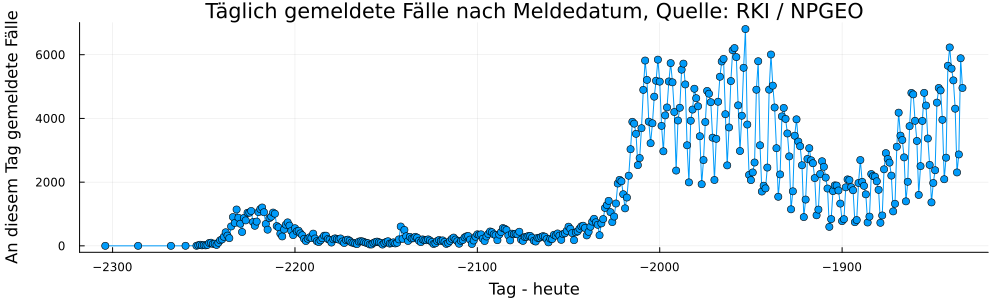

In [23]:
# 3. Plotten
plot(days, cases_all, 
    marker = :dot,
    size = (1000, 300),
    xlabel = "Tag - heute", 
    ylabel = "An diesem Tag gemeldete Fälle", 
    title = "Täglich gemeldete Fälle nach Meldedatum, Quelle: RKI / NPGEO",
    legend = false,
    # increase margins such that the axis labels are not cut off
    left_margin = 5Plots.mm,
    bottom_margin = 5Plots.mm
)

### b) Smoothing

Wie wir sehen sind die Daten recht unstetig (Was ist die Ursache für das periodische Auftreten der Peaks?). Für eine schönere Darstellung wollen wir einen gleitenden Mittelwert der Kurve bestimmen. Gehen Sie hierfür durch den Vektor `cases_all` und speichern den Mittelwert über die letzten `n` Fallzahlen. Probieren Sie verschiedene Werte für `n` aus. *Hinweis: Sie können die Funktion `mean(v::Array)` verwenden.*

Plotten Sie dann die geglätteten Fallzahlen gegen `days`. *Hinweis: Achten Sie auf die länge beider Vektoren*

In [24]:
cases_averaged = zeros(length(times))

n = 
for i in n+1:length(times)
    
    #= Hier kommt Ihr Code hin =#
    
end

UndefVarError: UndefVarError: `n` not defined

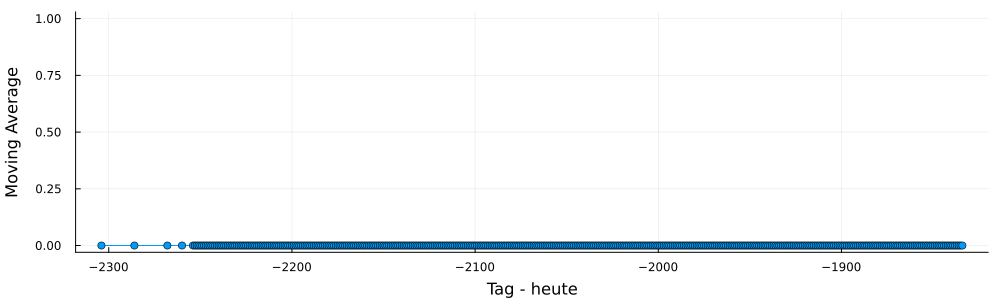

In [26]:
plot(days, cases_averaged, 
    marker = :dot,
    size = (1000, 300),
    xlabel = "Tag - heute", 
    ylabel = "Moving Average", 
    legend = false,
    # increase margins such that the axis labels are not cut off
    left_margin = 5Plots.mm,
    bottom_margin = 5Plots.mm
)

### c) Aufintegrieren

Integrieren Sie die (ungeglätteten !) Fallzahlen `cases_all` auf, d.h. bestimmen Sie pro Tag in `days` die Gesamtzahl bisher gemeldeter Fälle $c^{tot}_t = \sum_{i=0}^t c_i$, und tragen Sie die resultierende kumulative Kurve wieder gegen die Zeit auf.

In [ ]:
cases_total = 

plot(days, cases_total, 
    marker = :dot,
    size = (1000, 300),
    xlabel = "Tag - heute", 
    legend = false,
    # increase margins such that the axis labels are not cut off
    left_margin = 5Plots.mm,
    bottom_margin = 5Plots.mm
)

### d) Ableiten

Bilden Sie eine einfache Ableitung der kumulativen Kurve, speichern Sie das Ergebnis im Vektor `diff` ab und tragen Sie es
wieder gegen die Zeit auf.

$$ \delta_i = \frac{c^{tot}_{i+1} - c^{tot}_{i-1}}{t_{i+1} - t_{i-1}} $$

In [ ]:
diff = 

#= Hier kommt Ihr Code hin =#


### e) Lokale Tangente als Ableitung

Sie werden bemerkt haben, dass der grobe Trend der Ableitung durch ein leichtes Rauschen in den erhobenen Daten stark gestört wird. Um die Daten daher besser analysieren zu können, erinnern wir uns daran, dass die Ableitung einer Funktion letztendlich nichts anderes als eine lokale lineare Approximation ist. Wir können also die Ableitung berechnen, indem wir an jeden Punkt eine Tangente anlegen. Diese berechnen wir mittels linearer Regression. Die Tangente an Punkt $x_i$ ist gegeben durch
$y=b_i \cdot x + a_i,$
wobei hier die Steigung $b_i$ schon die Ableitung am Punkt $x_i$ ist. Diese Steigung $b_i$ ergibt sich aus:

$\quad b_i = \frac{\sum_{j=i-n}^{i+n}\left(x_j-\bar{x}_i\right)\left(y_j-\bar{y}_i\right)}{\sum_{j=i-n}^{i+n}\left(x_j - \bar{x}_i\right)^2}.$

Die Mittelwerte sind definiert durch

$\quad \bar{x}_i = \frac{1}{2n+1}\sum\limits_{j=i-n}^{i+n} x_j, \qquad \bar{y}_i = \frac{1}{2n+1}\sum\limits_{j=i-n}^{i+n} y_j.$

#### Lineare Regression: Beispiel

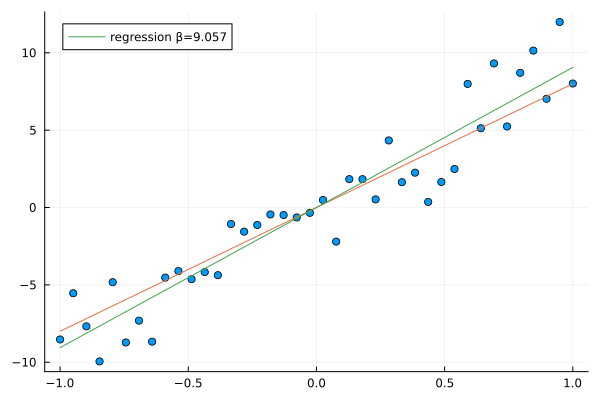

In [34]:
x = collect( range(0., 2., length=40) )
α = 8.
y = α .* x .+ 2*randn(length(x))

x .-= mean(x)
y .-= mean(y)

β = sum(x.*y) / sum(x.^2)
# β = inv(x'*x) * x'*y

scatter(x, y, label="")
plot!(x, α .* x, label="")
plot!(x, β .* x, label="regression β=$(round(β,digits=3))")

Implementieren Sie die lokale Approximation und plotten Sie dann die Ableitung der vorherigen Daten in den Arrays `days` und `cases_total` für verschiedene `n`. 
Vergleichen Sie Ihr Ergebnis zur zuvor in a) geglätteten Kurve und erklären Sie welche Probleme man beachten muss.

In [ ]:
n = 
diff = zeros(length(days))

for i = n+1:length(days) -n
    
    #= Hier kommt Ihr Code hin =#
    
end

plot( #= ... =# )